In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd          # pandas before torch (our Windows import-order rule)

PROTOCOL = ROOT / "data" / "PAMAP2_Dataset" / "Protocol"

# Files are whitespace-separated, no header, 54 columns. Missing values are 'NaN'.
df = pd.read_csv(PROTOCOL / "subject101.dat", sep=r"\s+", header=None)
print("Shape:", df.shape, "| duration (min):", round(len(df) / 100 / 60, 1))

print("\nActivity IDs present (col 1) and their counts:")
print(df[1].value_counts().sort_index())

print(f"\nHeart-rate (col 2) NaN fraction: {df[2].isna().mean():.3f}")
print(f"IMU columns NaN fraction (cols 3-53): {df.iloc[:, 3:].isna().mean().mean():.4f}")

Shape: (376417, 54) | duration (min): 62.7

Activity IDs present (col 1) and their counts:
1
0     126460
1      27187
2      23480
3      21717
4      22253
5      21265
6      23575
7      20265
12     15890
13     14899
16     22941
17     23573
24     12912
Name: count, dtype: int64

Heart-rate (col 2) NaN fraction: 0.909
IMU columns NaN fraction (cols 3-53): 0.0029


In [2]:
import importlib, src.pamap2
importlib.reload(src.pamap2)
from src.pamap2 import load_subject, make_windows, ACTIVITY_MAP, get_protocol_dir

PROTOCOL = get_protocol_dir()
subjects = {}
for f in sorted(PROTOCOL.glob("subject10*.dat")):
    sid = int(f.stem[-3:])                 # 101..109
    X, y = load_subject(f)                 # downsampled to 50 Hz, 18 channels
    subjects[sid] = (X, y)
    print(f"subject {sid}: {X.shape[0]:>6} samples | transient(0) {np.mean(y==0):.0%}")

print("\nTotal samples @50Hz:", sum(X.shape[0] for X, _ in subjects.values()))

subject 101: 188209 samples | transient(0) 34%
subject 102: 223500 samples | transient(0) 41%
subject 103: 126417 samples | transient(0) 31%
subject 104: 164788 samples | transient(0) 30%
subject 105: 187392 samples | transient(0) 27%
subject 106: 180909 samples | transient(0) 31%
subject 107: 156800 samples | transient(0) 26%
subject 108: 204016 samples | transient(0) 36%
subject 109:   4239 samples | transient(0) 25%

Total samples @50Hz: 1436270


In [3]:
def build(transition_aware):
    Xs, ys, sids = [], [], []
    for sid, (X, y) in subjects.items():
        w, l = make_windows(X, y, win=128, step=64, transition_aware=transition_aware)
        Xs.append(w); ys.append(l); sids.append(np.full(len(l), sid))
    return np.concatenate(Xs), np.concatenate(ys), np.concatenate(sids)

Xw_clean, yw_clean, sid_clean = build(transition_aware=True)    # single-activity windows only
Xw_naive, yw_naive, sid_naive = build(transition_aware=False)   # majority-label, keeps boundaries

print("Transition-aware (clean):", Xw_clean.shape, "| classes:", len(np.unique(yw_clean)))
print("Naive (majority label)  :", Xw_naive.shape, "| classes:", len(np.unique(yw_naive)))
extra = len(yw_naive) - len(yw_clean)
print(f"\nNaive keeps {extra} extra windows "
      f"({extra/len(yw_naive):.1%} of naive windows straddle a transition/boundary)")

Transition-aware (clean): (14971, 128, 18) | classes: 12
Naive (majority label)  : (15179, 128, 18) | classes: 12

Naive keeps 208 extra windows (1.4% of naive windows straddle a transition/boundary)


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
from src.model import HAR_CNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(42); torch.manual_seed(42)

# PAMAP2 activity ids are non-contiguous (1..24) -> remap to 0..11 for the loss.
acts = sorted(ACTIVITY_MAP.keys())
act_to_idx = {a: i for i, a in enumerate(acts)}
class_names_p = [ACTIVITY_MAP[a] for a in acts]

def make_loader(X, y, bs=64, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)          # (n,18,128)
    yt = torch.tensor([act_to_idx[a] for a in y], dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=bs, shuffle=shuffle)

def train(model, loader, epochs=20, lr=5e-4):
    model = model.to(device)
    crit, opt = nn.CrossEntropyLoss(), torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
    return model

def predict(model, loader):
    model.eval(); P, T = [], []
    with torch.no_grad():
        for xb, yb in loader:
            P.append(model(xb.to(device)).argmax(1).cpu().numpy()); T.append(yb.numpy())
    return np.concatenate(P), np.concatenate(T)

print("device:", device, "| classes:", len(acts))

device: cuda | classes: 12


In [5]:
test_subjects = {107, 108}                      # 2 unseen subjects for test
tr = ~np.isin(sid_clean, list(test_subjects))
te =  np.isin(sid_clean, list(test_subjects))

# Standardize per channel using TRAIN stats only
m = Xw_clean[tr].mean(axis=(0, 1)); s = Xw_clean[tr].std(axis=(0, 1))
train_loader = make_loader((Xw_clean[tr] - m) / s, yw_clean[tr], shuffle=True)
test_loader  = make_loader((Xw_clean[te] - m) / s, yw_clean[te])

torch.manual_seed(42)
pamap_cnn = train(HAR_CNN(n_channels=18, n_classes=12, dropout=0.5), train_loader, epochs=20)
P, T = predict(pamap_cnn, test_loader)

print(f"PAMAP2 CNN (subject-independent, clean windows)")
print(f"  train windows: {tr.sum()} | test windows: {te.sum()} | test subjects: {test_subjects}")
print(f"  accuracy {accuracy_score(T, P):.4f} | macro-F1 {f1_score(T, P, average='macro'):.4f}")

PAMAP2 CNN (subject-independent, clean windows)
  train windows: 11154 | test windows: 3817 | test subjects: {107, 108}
  accuracy 0.5944 | macro-F1 0.5792


In [6]:
# 1) Did the model actually fit the training data?
Ptr, Ttr = predict(pamap_cnn, train_loader)
print(f"TRAIN accuracy: {accuracy_score(Ttr, Ptr):.4f}")

# 2) Break the test score down by subject (is one subject dragging it?)
for sub in sorted(test_subjects):
    mask = sid_clean == sub
    Ps, Ts = predict(pamap_cnn, make_loader((Xw_clean[mask] - m) / s, yw_clean[mask]))
    print(f"  test subject {sub}: acc {accuracy_score(Ts, Ps):.3f}  (n={mask.sum()})")

# 3) Which classes collapse? (per-class recall on test)
from sklearn.metrics import classification_report
print(classification_report(T, P, target_names=class_names_p, digits=2, zero_division=0))

TRAIN accuracy: 0.9743
  test subject 107: acc 0.853  (n=1795)
  test subject 108: acc 0.364  (n=2022)
                   precision    recall  f1-score   support

            lying       0.92      0.50      0.65       384
          sitting       0.23      0.66      0.34       272
         standing       0.66      0.33      0.44       393
          walking       0.98      0.50      0.66       507
          running       0.74      0.84      0.79       154
          cycling       0.59      0.75      0.66       374
   nordic_walking       0.94      0.48      0.64       445
 ascending_stairs       0.88      0.76      0.82       224
descending_stairs       0.28      0.80      0.41       157
        vacuuming       0.69      0.85      0.76       355
          ironing       0.71      0.60      0.65       485
     rope_jumping       1.00      0.07      0.14        67

         accuracy                           0.59      3817
        macro avg       0.72      0.60      0.58      3817
     weigh

In [7]:
uniq_sub = sorted(subjects.keys())
loso_acc = {}
for held in uniq_sub:
    tr, te = sid_clean != held, sid_clean == held
    if te.sum() < 30:                      # skip subject 109 (too few windows)
        print(f"held-out subject {held}: skipped (only n={te.sum()})"); continue
    m_ = Xw_clean[tr].mean(axis=(0, 1)); s_ = Xw_clean[tr].std(axis=(0, 1))
    trl = make_loader((Xw_clean[tr] - m_) / s_, yw_clean[tr], shuffle=True)
    tel = make_loader((Xw_clean[te] - m_) / s_, yw_clean[te])
    torch.manual_seed(42)
    mdl = train(HAR_CNN(n_channels=18, n_classes=12, dropout=0.5), trl, epochs=15)
    Pp, Tt = predict(mdl, tel)
    loso_acc[held] = accuracy_score(Tt, Pp)
    print(f"held-out subject {held}: acc {loso_acc[held]:.3f}  (n={te.sum()})")

vals = np.array(list(loso_acc.values()))
print(f"\nPAMAP2 LOSO accuracy: {vals.mean():.4f} ± {vals.std():.4f}  "
      f"| worst: subject {min(loso_acc, key=loso_acc.get)} ({vals.min():.3f})")

held-out subject 101: acc 0.788  (n=1926)
held-out subject 102: acc 0.738  (n=2029)
held-out subject 103: acc 0.810  (n=1340)
held-out subject 104: acc 0.782  (n=1782)
held-out subject 105: acc 0.863  (n=2103)
held-out subject 106: acc 0.877  (n=1926)
held-out subject 107: acc 0.818  (n=1795)
held-out subject 108: acc 0.298  (n=2022)
held-out subject 109: acc 0.833  (n=48)

PAMAP2 LOSO accuracy: 0.7564 ± 0.1670  | worst: subject 108 (0.298)


In [8]:
def get_boundary(X, y, win=128, step=64):
    """Windows that straddle a transition: mixed content, non-zero majority label."""
    W, L = [], []
    for st in range(0, len(X) - win + 1, step):
        seg = y[st:st + win]
        vals, cnts = np.unique(seg, return_counts=True)
        maj = vals[cnts.argmax()]
        if maj != 0 and not np.all(seg == maj):
            W.append(X[st:st + win]); L.append(maj)
    return np.asarray(W), np.asarray(L)

test_sub = {105, 106}                        # "normal" subjects (avoid 108 confound)
trm = ~np.isin(sid_clean, list(test_sub))
m2 = Xw_clean[trm].mean(axis=(0, 1)); s2 = Xw_clean[trm].std(axis=(0, 1))

torch.manual_seed(42)
probe = train(HAR_CNN(n_channels=18, n_classes=12, dropout=0.5),
              make_loader((Xw_clean[trm] - m2) / s2, yw_clean[trm], shuffle=True), epochs=20)

# (a) clean single-activity test windows
tem = np.isin(sid_clean, list(test_sub))
Pc, Tc = predict(probe, make_loader((Xw_clean[tem] - m2) / s2, yw_clean[tem]))
clean_acc = accuracy_score(Tc, Pc)

# (b) boundary/transition windows for the same subjects
Xb = np.concatenate([get_boundary(*subjects[s])[0] for s in test_sub])
yb = np.concatenate([get_boundary(*subjects[s])[1] for s in test_sub])
Pb, Tb = predict(probe, make_loader((Xb - m2) / s2, yb))
boundary_acc = accuracy_score(Tb, Pb)

print(f"Clean (single-activity) windows : acc {clean_acc:.3f}  (n={tem.sum()})")
print(f"Boundary (transition)  windows  : acc {boundary_acc:.3f}  (n={len(yb)})")
print(f"Accuracy drop on boundary windows: {clean_acc - boundary_acc:+.3f}")

Clean (single-activity) windows : acc 0.837  (n=4029)
Boundary (transition)  windows  : acc 0.075  (n=53)
Accuracy drop on boundary windows: +0.761


Saved: C:\Users\abel\Documents\Python_projects\The HAR project\reports\figures\pamap2_results.png


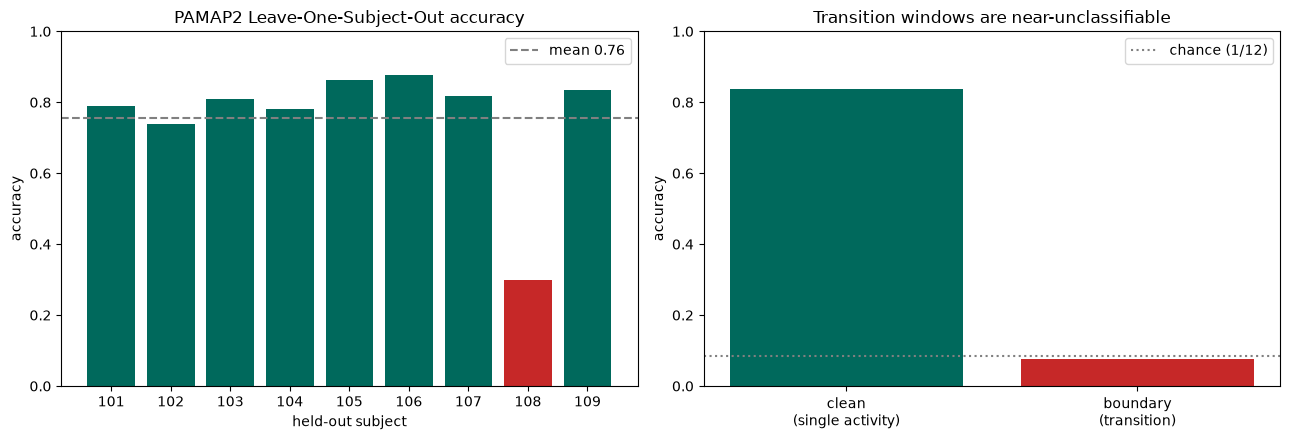

In [9]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: PAMAP2 LOSO per-subject (highlight the outlier)
subs = list(loso_acc.keys())
accs = [loso_acc[k] for k in subs]
ax1.bar([str(s) for s in subs], accs,
        color=["#C62828" if a < 0.5 else "#00695C" for a in accs])
ax1.axhline(np.mean(accs), ls="--", color="gray", label=f"mean {np.mean(accs):.2f}")
ax1.set_title("PAMAP2 Leave-One-Subject-Out accuracy")
ax1.set_xlabel("held-out subject"); ax1.set_ylabel("accuracy"); ax1.set_ylim(0, 1); ax1.legend()

# Right: clean vs boundary windows
ax2.bar(["clean\n(single activity)", "boundary\n(transition)"], [clean_acc, boundary_acc],
        color=["#00695C", "#C62828"])
ax2.axhline(1/12, ls=":", color="gray", label="chance (1/12)")
ax2.set_title("Transition windows are near-unclassifiable")
ax2.set_ylabel("accuracy"); ax2.set_ylim(0, 1); ax2.legend()

plt.tight_layout()
fig_dir = next(p for p in [Path("reports/figures"), Path("../reports/figures")] if p.exists())
fig.savefig(fig_dir / "pamap2_results.png", dpi=150, bbox_inches="tight")
print("Saved:", (fig_dir / "pamap2_results.png").resolve())
plt.show()